In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize
import statsmodels.stats.anova
from matplotlib.pyplot import subplots

In [2]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [3]:
auto = load_data("auto")
y = auto["mpg"]
X = auto.drop(columns=["mpg", "name"])

## Scaling of the data

The VIF values should be calculated on the scaled data.

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_train)
scaled_data_df_Xtrain = pd.DataFrame(scaled_data, columns=X_train.columns)
scaled_data_df_Xtrain.insert(0,'constant',1)

In [6]:
scaled_data_df_Xtrain.head(2)

,constant,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,1,0.304862,0.284578,0.141429,0.754803,1.121759,0.494528,-0.689825
1,1,-0.873184,-0.535880,-0.329499,-0.493129,-0.228940,-0.057298,-0.689825


In [7]:
vif_values = [VIF(scaled_data_df_Xtrain, i) for i in range(1,scaled_data_df_Xtrain.shape[1])]
vif_values_df = pd.DataFrame({"vif": vif_values}, index=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin'])
vif_values_df

,vif
cylinders,11.120880
displacement,21.490339
horsepower,9.929576
weight,10.157723
acceleration,2.682152
year,1.280903
origin,1.753601


In [8]:
X1 = scaled_data_df_Xtrain.drop(columns=["displacement"])
vif_values_X1 = [VIF(X1, i) for i in range(1,X1.shape[1])]
vif_values_X1_df = pd.DataFrame({"vif": vif_values_X1}, index=X1.columns[1:])
vif_values_X1_df

,vif
cylinders,5.877208
horsepower,9.199354
weight,8.755609
acceleration,2.656988
year,1.273053
origin,1.573116


In [9]:
X1 = X1.drop(columns=["horsepower"])
vif_values_X1 = [VIF(X1, i) for i in range(1,X1.shape[1])]
vif_values_X1_df = pd.DataFrame({"vif": vif_values_X1}, index=X1.columns[1:])
vif_values_X1_df

,vif
cylinders,5.764093
weight,5.249765
acceleration,1.367232
year,1.188107
origin,1.531637


In [10]:
# we are removing the "displacement" and "horsepower" features from our scaled data
scaled_data_df_Xtrain.drop(columns=["displacement", "horsepower"], inplace=True)

1. Applying the scaling to the X_test. (remember: remove the "High VIF predictors")
2. y_train, y_test doesn't need the scaling
2. Removing the High P-value predictors

In [11]:
scaled_data_X_test = scaler.fit_transform(X_test)
scaled_data_df_X_test = pd.DataFrame(scaled_data_X_test, columns=X_test.columns)
scaled_data_df_X_test.insert(0,"constant",1)

In [12]:
scaled_data_df_X_test.drop(columns=["displacement", "horsepower"], inplace=True)

## Removing the high P-value variables

In [13]:
y_train.index

Index([258, 182, 172,  63, 340, 229, 329, 380, 278, 220,
       ...
       214, 121, 391,  20, 188,  71, 106, 270, 348, 102],
      dtype='int64', length=313)

In [14]:
y_train.reset_index(drop=True, inplace=True)

In [15]:
y_train.index

RangeIndex(start=0, stop=313, step=1)

In [16]:
scaled_data_df_Xtrain.index

RangeIndex(start=0, stop=313, step=1)

In [17]:
model = sm.OLS(y_train,scaled_data_df_Xtrain).fit()
summarize(model)

,coef,std err,t,P>|t|
constant,23.5994,0.190,123.980,0.000
cylinders,0.1278,0.457,0.280,0.780
weight,-5.0824,0.436,-11.653,0.000
acceleration,0.2500,0.223,1.123,0.262
year,2.8032,0.207,13.510,0.000
origin,1.1215,0.236,4.761,0.000


In [18]:
dummy_Xtrain = scaled_data_df_Xtrain.drop(columns=["cylinders"])
dummy_model = sm.OLS(y_train,dummy_Xtrain).fit()
summarize(dummy_model)

,coef,std err,t,P>|t|
constant,23.5994,0.190,124.166,0.000
weight,-4.9832,0.254,-19.648,0.000
acceleration,0.2304,0.211,1.092,0.276
year,2.7957,0.205,13.608,0.000
origin,1.1131,0.233,4.771,0.000


In [19]:
scaled_data_df_Xtrain.drop(columns=["cylinders", "acceleration"], inplace=True)
model_actual = sm.OLS(y_train,scaled_data_df_Xtrain).fit()
summarize(model_actual)

,coef,std err,t,P>|t|
constant,23.5994,0.190,124.127,0.0
weight,-5.0607,0.244,-20.778,0.0
year,2.8404,0.201,14.104,0.0
origin,1.1102,0.233,4.757,0.0


In [20]:
scaled_data_df_X_test.drop(columns=['cylinders', 'acceleration'], inplace=True)

In [21]:
y_pred = model_actual.predict(scaled_data_df_X_test)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2_value: ", r2_score(y_test, y_pred)) # tell how much our model tells the variation of response with respect to predictors

R2_value:  0.7810482809354646


In [23]:
print("MSE value: ", mean_squared_error(y_test,y_pred)) # gives the average value by which our actual values and predicted values varies

MSE value:  11.175423442425044


In [24]:
from sklearn.metrics import mean_absolute_percentage_error
print("MAPE Value: ", mean_absolute_percentage_error(y_test, y_pred)) # gives the error by which our model differ in making the prediction.
# in our model it is 11% means our model is 89% accurate

MAPE Value:  0.11365159698212178


## Some graphs

In [25]:
scaled_data_df_X_test.columns

Index(['constant', 'weight', 'year', 'origin'], dtype='object')

In [26]:
type(y_train)

pandas.core.series.Series

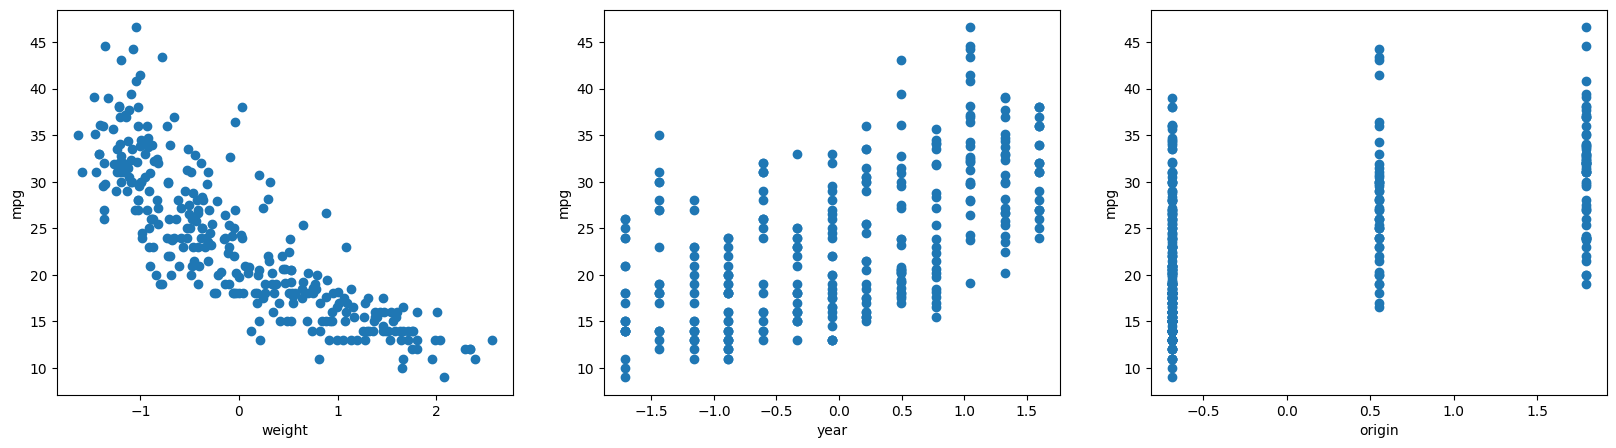

In [27]:
plt.figure(figsize=(20,5))
plt.subplot(131);plt.scatter(y=y_train, x=scaled_data_df_Xtrain["weight"]);plt.xlabel("weight");plt.ylabel("mpg");
plt.subplot(132);plt.scatter(y=y_train, x=scaled_data_df_Xtrain["year"]);plt.xlabel("year");plt.ylabel("mpg");
plt.subplot(133);plt.scatter(y=y_train, x=scaled_data_df_Xtrain["origin"]);plt.xlabel("origin");plt.ylabel("mpg");

In [28]:
model_actual.params

constant    23.599361
weight      -5.060729
year         2.840369
origin       1.110178
dtype: float64

C:\Users\AAYUSH OJHA\AppData\Local\Temp\ipykernel_19840\376077420.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_lim = [model_actual.params[0] + (model_actual.params[1]*x_lim[0]), model_actual.params[0] + (model_actual.params[1]*x_lim[1])]


Text(0, 0.5, 'mpg')

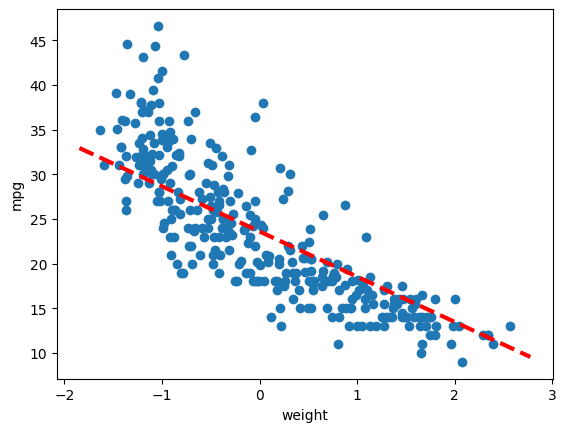

In [29]:
plt.scatter(y=y_train, x=scaled_data_df_Xtrain["weight"])
x_lim = plt.xlim()
y_lim = [model_actual.params[0] + (model_actual.params[1]*x_lim[0]), model_actual.params[0] + (model_actual.params[1]*x_lim[1])]
plt.plot(x_lim, y_lim, "r--", linewidth=3)
plt.plot()
plt.xlabel("weight")
plt.ylabel("mpg")

## Residual Plot

Text(0, 0.5, 'Residuals')

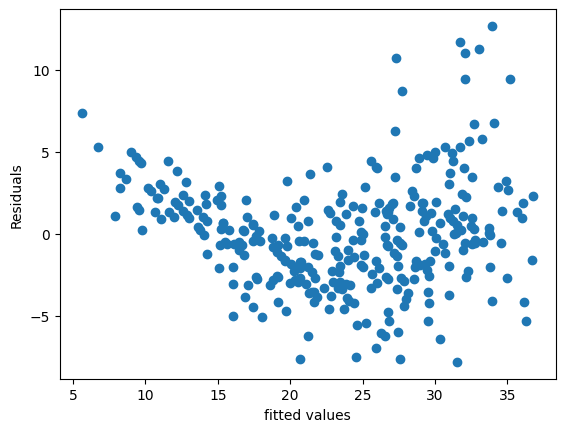

In [30]:
plt.scatter(x=model.fittedvalues, y=model.resid)
plt.xlabel("fitted values")
plt.ylabel("Residuals")

## Applying log on the response

In [31]:
type(y_train)

pandas.core.series.Series

In [32]:
type(np.log(y_train))

pandas.core.series.Series

In [33]:
model_fitting = sm.OLS(np.log(y_train),scaled_data_df_Xtrain).fit()
summarize(model_fitting)

,coef,std err,t,P>|t|
constant,3.1033,0.007,449.097,0.0
weight,-0.2425,0.009,-27.396,0.0
year,0.1196,0.007,16.338,0.0
origin,0.0329,0.008,3.876,0.0


In [34]:
y_pred1 = model_fitting.predict(scaled_data_df_X_test)

In [35]:
y_pred_actual = np.exp(y_pred1)
print("R2: ", r2_score(y_test, y_pred_actual))
print("MAPE: ", mean_absolute_percentage_error(y_test, y_pred_actual))

R2:  0.843450180363584
MAPE:  0.08837108812635824


1. use the interaction terms
2. use the polynomial regression also

## Interaction terms

In [36]:
interaction_X_train = scaled_data_df_Xtrain
interaction_X_train['weight_year'] = (interaction_X_train['weight']* interaction_X_train['year'])
interaction_X_train['weight_origin'] = (interaction_X_train['weight']* interaction_X_train['origin'])
interaction_X_train['year_origin'] = (interaction_X_train['year']*interaction_X_train['origin'])
interaction_X_train['weight_year_origin'] = (interaction_X_train['weight']* interaction_X_train['year']*interaction_X_train ['origin'])

In [37]:
interaction_X_train.head(2)

,constant,weight,year,origin,weight_year,weight_origin,year_origin,weight_year_origin
0,1,0.754803,0.494528,-0.689825,0.373271,-0.520682,-0.341137,-0.257491
1,1,-0.493129,-0.057298,-0.689825,0.028255,0.340173,0.039526,-0.019491


In [38]:
interaction_model = sm.OLS(np.log(y_train), interaction_X_train).fit()

In [39]:
summarize(interaction_model)

,coef,std err,t,P>|t|
constant,3.0830,0.011,285.728,0.000
weight,-0.2630,0.012,-22.745,0.000
year,0.1480,0.011,13.300,0.000
origin,0.0155,0.014,1.080,0.281
weight_year,0.0090,0.012,0.776,0.439
weight_origin,-0.0216,0.014,-1.531,0.127
year_origin,0.0327,0.015,2.242,0.026
weight_year_origin,0.0522,0.014,3.649,0.000


In [40]:
interaction_X_train.drop(columns=['weight_year', 'weight_origin'], inplace=True)

In [41]:
interaction_X_train['weight_origin'] = (interaction_X_train['weight']* interaction_X_train['origin'])

In [42]:
interaction_X_train.drop(columns=["weight_origin"], inplace=True)

In [43]:
interaction_model = sm.OLS(np.log(y_train), interaction_X_train).fit()
summarize(interaction_model)

,coef,std err,t,P>|t|
constant,3.0948,0.007,427.511,0.000
weight,-0.2532,0.010,-26.594,0.000
year,0.1410,0.009,15.599,0.000
origin,0.0330,0.009,3.751,0.000
year_origin,0.0242,0.010,2.467,0.014
weight_year_origin,0.0441,0.011,3.884,0.000


In [44]:
interaction_X_test = scaled_data_df_X_test
interaction_X_test['year_origin'] = (interaction_X_test['year']*interaction_X_test['origin'])
interaction_X_test['weight_year_origin'] = (interaction_X_test['weight']* interaction_X_test['year']*interaction_X_test ['origin'])

In [45]:
interaction_predict = interaction_model.predict(interaction_X_test)

In [46]:
print("R2_value: ", r2_score(y_test, np.exp(interaction_predict)))
print("MAPE_value: ", mean_absolute_percentage_error(y_test, np.exp(interaction_predict)))

R2_value:  0.8399328352816543
MAPE_value:  0.09197228807175412


In [47]:
interaction_X_train['weight_squared'] = (interaction_X_train['weight']* interaction_X_train['weight'])

In [48]:
interaction_X_train.drop(columns=["year_origin"], inplace=True)

In [49]:
interaction_model_squared = sm.OLS(np.log(y_train), interaction_X_train).fit()
summarize(interaction_model_squared)

,coef,std err,t,P>|t|
constant,3.0707,0.010,312.362,0.000
weight,-0.2619,0.010,-27.318,0.000
year,0.1342,0.008,16.231,0.000
origin,0.0269,0.009,3.045,0.003
weight_year_origin,0.0183,0.008,2.234,0.026
weight_squared,0.0307,0.007,4.180,0.000


In [50]:
interaction_X_test["weight_squared"] = (interaction_X_test['weight']* interaction_X_test['weight'])

In [51]:
interaction_X_test.drop(columns=["year_origin"], inplace=True)

In [52]:
interaction_predict_squared = interaction_model_squared.predict(interaction_X_test)
print("R2_value: ", r2_score(y_test, np.exp(interaction_predict_squared)))
print("MAPE_value: ", mean_absolute_percentage_error(y_test, np.exp(interaction_predict_squared)))

R2_value:  0.8484619821044428
MAPE_value:  0.08839857179882567


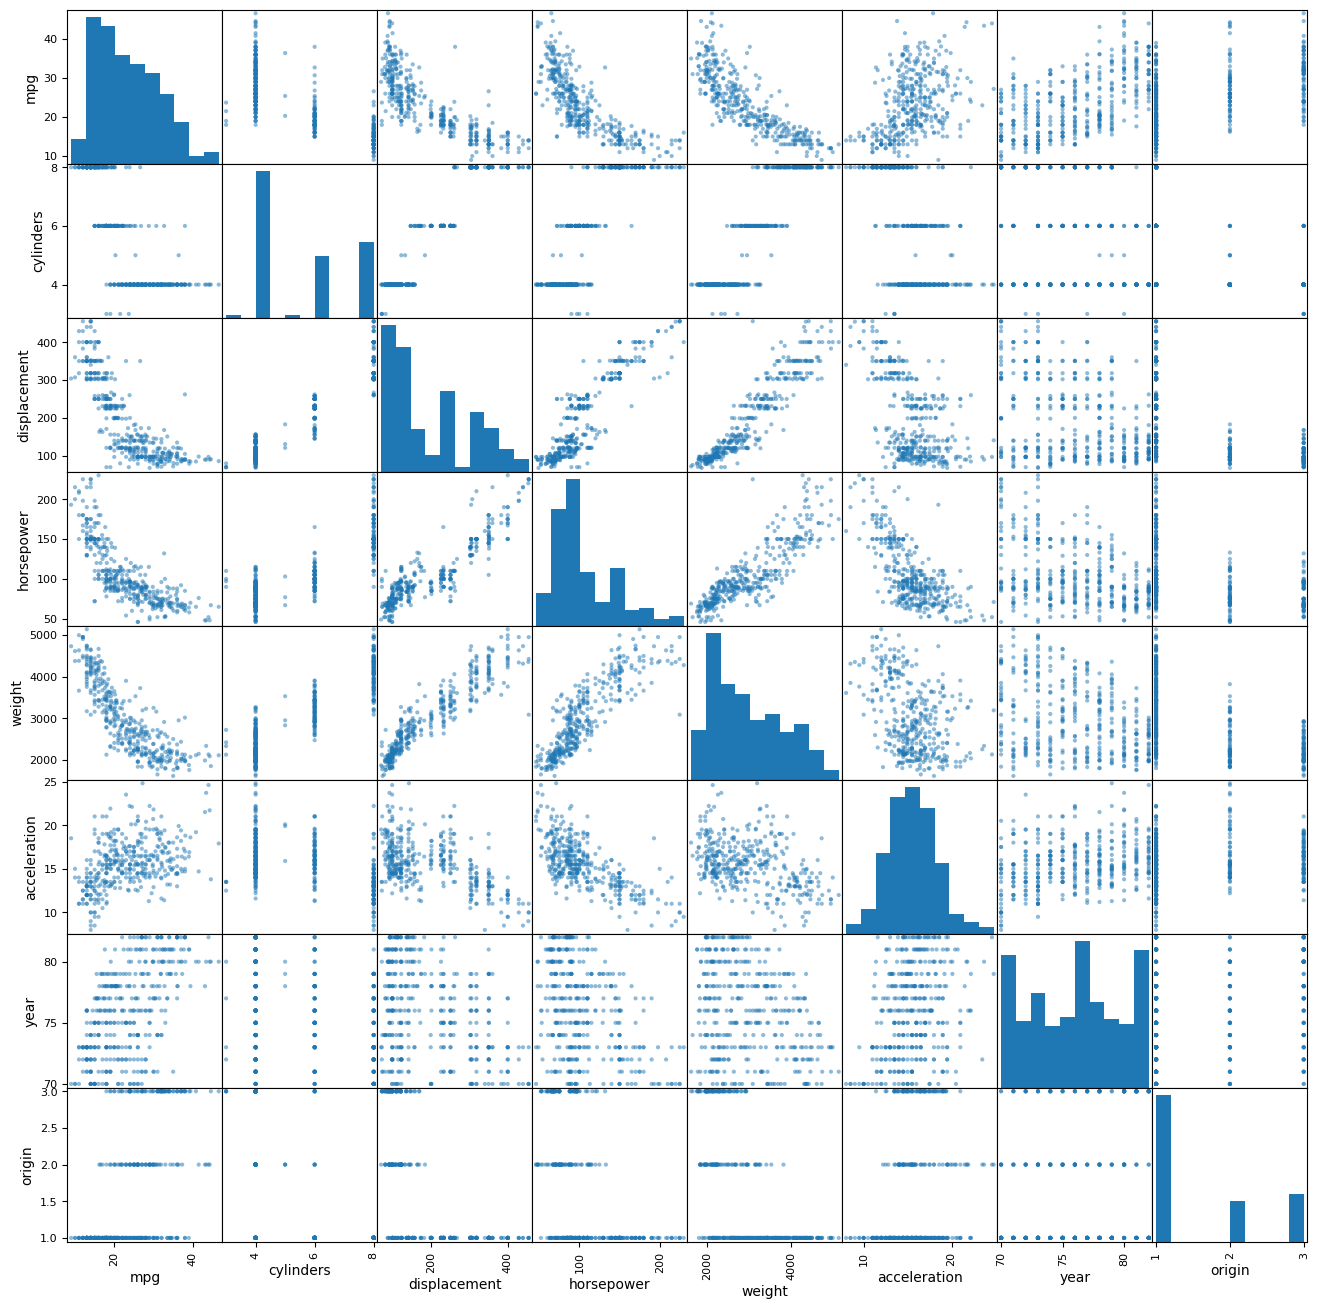

In [55]:
pd.plotting.scatter_matrix(auto, figsize=(16,16))
plt.show()

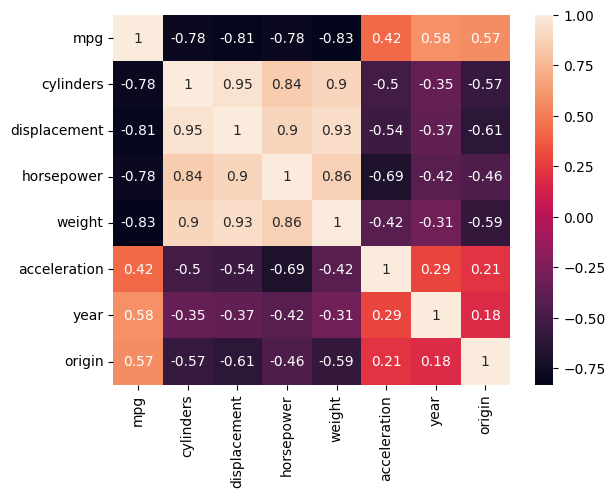

In [59]:
import seaborn as sns
sns.heatmap(dummy.corr(), annot=True);

In [58]:
dummy = auto.drop(columns=["name"])